In [1]:
# Set up the file path
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)
target_directory = '/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/'
sys.path.append(parent_dir)
print('Working directory set to:', parent_dir)
print('Target directory set to:', target_directory)

Parent directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Working directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Target directory set to: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [3]:
# Filename for loading the agent checkpoint
# load_path = '/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/models/' 
# get directory of this script (must work in a jupyter notebook as well)
load_path = os.path.join(target_directory, 'models')
print('Loading models from:', load_path)

# locate all files corresponding to *.pth in the subdirectory of load path
input_paths = []
for file in os.listdir(load_path):
    if file.endswith('.pth') and not file.startswith('generated_'):
        input_paths.append(os.path.join(load_path, file))

save_flag = True                # Save the results of the obtained IOCRNs

# No logger needed
logger = None

Loading models from: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/models


In [4]:
# Construct the template CRN
r1 = MassAction(reactant_labels=['Z'], product_labels=[], input_channels=['u_1'], params=[1.], params_controllability=[True])
r2 = MassAction(reactant_labels=['X'], product_labels=[], input_channels=['u_2'], params=[1.], params_controllability=[True])
crn_template = IOCRN([r1, r2], output_labels=['X'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
species_labels = ['X', 'Z']
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2'] 
Species: ['X', 'Z'] 
Output Species: ['X'] 
Z ----> ∅;  [MAK(1.0, u_1)]
X ----> ∅;  [MAK(1.0, u_2)]
Library of possible reactions:
Number of reactions: 31
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X;  [MAK(None)]
R2: ∅ ----> Z;  [MAK(None)]
R3: ∅ ----> X + X;  [MAK(None)]
R4: ∅ ----> X + Z;  [MAK(None)]
R5: ∅ ----> Z + Z;  [MAK(None)]
R6: X ----> ∅;  [MAK(None)]
R7: X ----> Z;  [MAK(None)]
R8: X ----> X + X;  [MAK(None)]
R9: X ----> X + Z;  [MAK(None)]
R10: X ----> Z + Z;  [MAK(None)]
R11: Z ----> ∅;  [MAK(None)]
R12: Z ----> X;  [MAK(None)]
R13: Z ----> X + X;  [MAK(None)]
R14: Z ----> X + Z;  [MAK(None)]
R15: Z ----> Z + Z;  [MAK(None)]
R16: X + X ----> ∅;  [MAK(None)]
R17: X + X ----> X;  [MAK(None)]
R18: X + X ----> Z;  [MAK(None)]
R19: X + X ----> X + Z;  [MAK(None)]
R20: X + X ----> Z + Z;  [MAK(None)]
R21: X + Z ----> ∅;  [MAK(None)]
R22: X + Z ----> X;  [MAK(None)]
R23: X + Z ----> Z;  [MAK(None)]
R24: X + Z ----> X + X;  [MAK(None)]
R25: X +

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [6]:
# Hyperparameters
max_added_reactions = 4                                 # Maximum number of reactions
N_CPUs = os.cpu_count()                                 # Number of CPUs          
N = 10*N_CPUs                                           # Number of samples (batch size)    
width = 1024                                            # Width of the neural networks  
depth = 5                                               # Depth of the neural networks 
deep_layer_size = 1024*10                               # Size of the deep layer encoding the CRNs
allow_input_influence = False                           # Allow input influence in the policy
learning_rate = 1e-4                                    # Learning rate for the optimizer 
hall_of_fame_size = 30                                  # Size of the hall of fame  
entropy_scheduler = {                                   # Entropy scheduler parameters 
    'entropy_weight': 3e-3,                            # Global entropy weight
    'entropy_weight_structure_head': 1.0,               # Entropy weight for the structure head
    'entropy_weight_continuous_head': 0.1,              # Entropy weight for the continuous parameters head
    'topk_entropy_weight': 1.0,                         # Entropy weight for the top-k actions
    'remainder_entropy_weight': 1.0,                    # Entropy weight for the remainder actions
    'entropy_update_coefficient': 1,                    # Entropy update coefficient (multiplicative)
    'entropy_schedule': 1000,                           # Entropy schedule (in epochs) 
    'minimum_entropy_weight': 0.0                       # Minimum entropy weight
}
structure_head_temperature = {
    'target_entropy_ratio_to_max': np.log(5)/np.log(M), 
    'initial_temperature': 1.0, 
    'rate': 0.0, 
    'current_temperature': 1.0}
risk_scheduler = {                                      # Risk scheduler parameters
    'risk': 0.9,                                        # Percentage of worst samples to disregard when computing the reward
    'risk_update': 0.0,                                 # Risk update coefficient (additive)
    'max_risk': 1.0,                                    # Maximum risk
    'risk_schedule': 1000                               # Risk schedule (in epochs)
}
epoch_num = 300                                         # Number of epochs for training
render_schedule = 10                                    # Render every # of epochs
render_mode = {                                         # Mode of the experiment
    'style': 'logger',                                  
    'task': 'transients', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
render_n_best = 3                                       # Number of best CRNs to plot responses for
render_disregard_percentage = risk_scheduler['risk']    # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}        

# Time horizon for the simulation
t_f = 100                                               # Final time for the simulation
N_t = 1000                                              # Number of time steps in the simulation
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
nums = [0.5, 1.0, 1.5]
u_list = [np.array(u) for u in product(nums, repeat=p)] # list of input combinations, each input is a numpy array of shape (p,)

# Construct the reference setpoints
r_list = [np.array([u[0]]) for u in u_list]

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.01, 0.01]])

# Construct the weights for the performance metric
w = np.ones(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
w = w[np.newaxis, :]

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

In [7]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [8]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
entropy_weights_per_head = {'structure': entropy_scheduler['entropy_weight_structure_head'], 'continuous': entropy_scheduler['entropy_weight_continuous_head'], 'discrete': 0.0, 'input_influence': 0.0} 
policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=allow_input_influence, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=allow_input_influence, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, device=device)

In [9]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [10]:
# Test the model
from tqdm import tqdm
sorted_crns_rewards_list = []
for p in tqdm(input_paths):
    agent.policy.load_state_dict(torch.load(p, map_location=device))

    agent.policy.eval()
    mult_env.reset()
    for j in range(max_added_reactions):
        observations = mult_env.observe(observer, tensorizer)
        actions, raw_actions = agent.act(observations, actuator)
        out = mult_env.step(actions, stepper, raw_actions=raw_actions)

    rewards = mult_env.get_reward(compute_reward)

    # Gather the CRNs from the environments
    crns = mult_env.gather()

    # Sort the CRNs by rewards
    sorted_crns_rewards = sorted(zip(crns, rewards), key=lambda x: x[1])
    sorted_crns_rewards_list.append(sorted_crns_rewards)

  0%|          | 0/4 [00:00<?, ?it/s]


[cvHandleFailure, Error: -15] At t = 9.4735718792339, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 21.1413928912941, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 19.0507357938809, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 30.5975843649156, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.9367317807765, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 49.7571749688571, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 63.9999080788405, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 10.5501390856926, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 23.167392223999, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.66433828198189, unable to satisfy inequality constraints.


[cvHandleFa

 25%|██▌       | 1/4 [00:09<00:27,  9.28s/it]


[cvHandleFailure, Error: -15] At t = 12.8703025912296, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 13.858764851639, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 22.0547683532316, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.61283764950812, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.6769448337107, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 30.5304665467887, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 19.8619922048345, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 18.4557014381786, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 20.5071963275028, unable to satisfy inequality constraints.



 50%|█████     | 2/4 [00:14<00:14,  7.06s/it]


[cvHandleFailure, Error: -15] At t = 24.4042160851306, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 6.67746197660924, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 15.4033573874439, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 12.4123788046662, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 13.3195707952519, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.44822429507279, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 17.7958627427402, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 8.23148721101592, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.74278402021809, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 6.57756208857164, unable to satisfy inequality constraints.


[cvHandle

 75%|███████▌  | 3/4 [00:20<00:06,  6.37s/it]


[cvHandleFailure, Error: -15] At t = 28.7511304257245, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 30.7325754478775, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 6.37416845069968, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 33.7016062604426, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 28.3929152285674, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 20.2406436633489, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 25.9355074149805, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 19.8092049594171, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 18.0462696236181, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 15.068549519287, unable to satisfy inequality constraints.


[cvHandleF

100%|██████████| 4/4 [00:25<00:00,  6.44s/it]


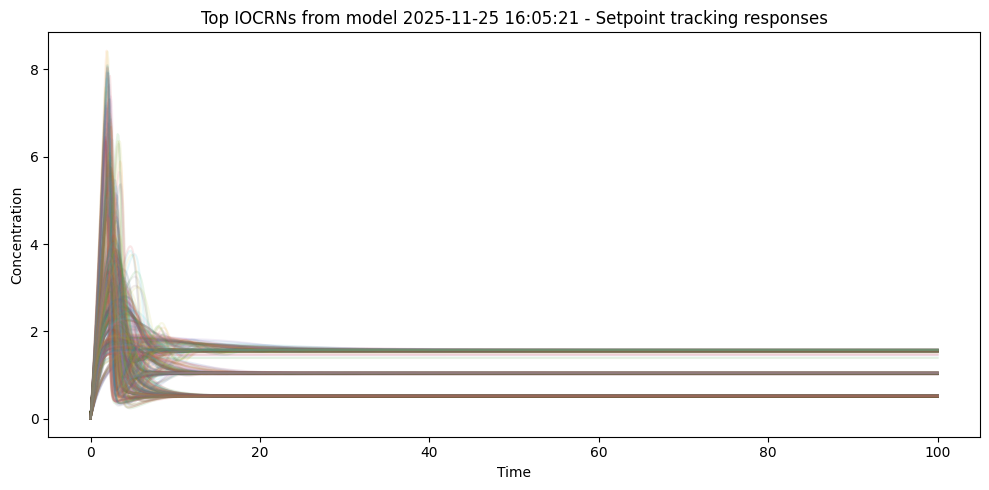

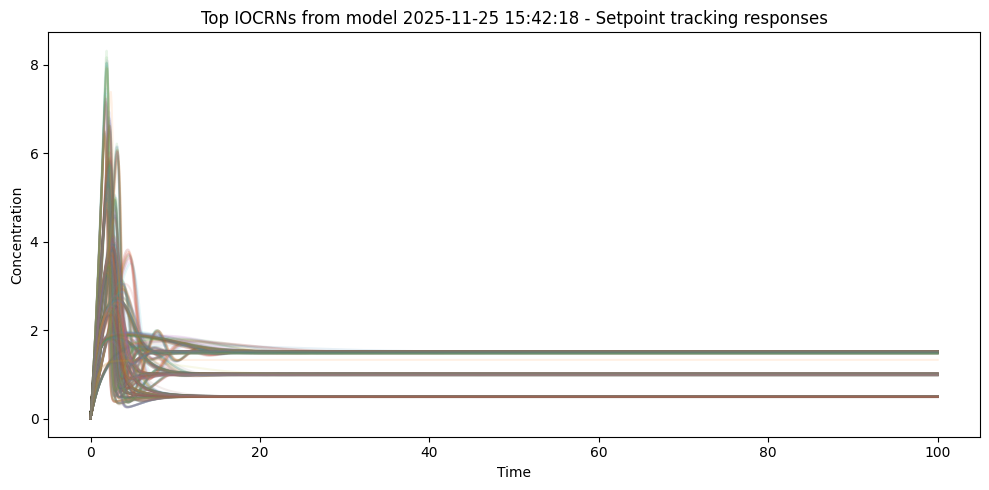

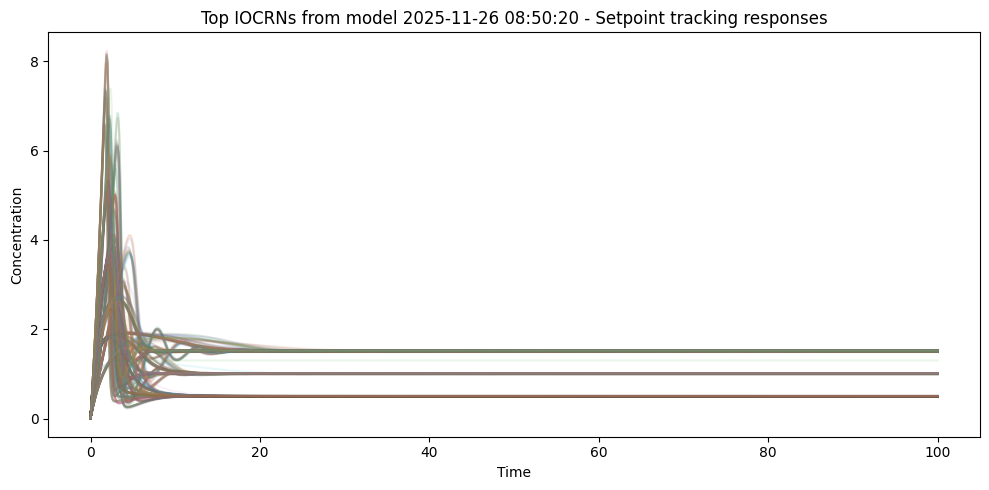

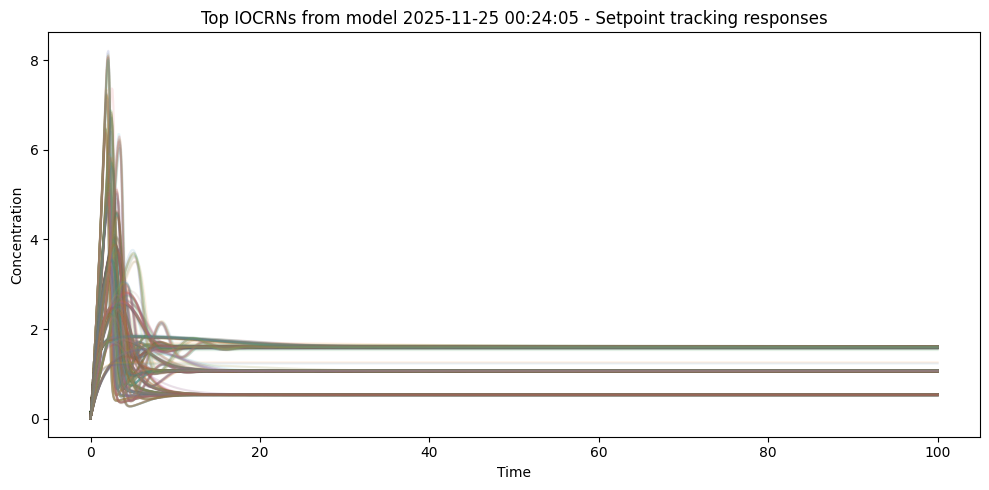

In [11]:
# Plot the results
for  j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
    n_plot = 100
    ax = None
    for i in range(n_plot):
        x0_list = ic.get_ic(sorted_crns_rewards[i][0])
        time_horizon, x_list, y_list, last_task_info = sorted_crns_rewards[i][0].transient_response(u_list, x0_list, time_horizon)
        fig, ax = sorted_crns_rewards[i][0].plot_transient_response(axes=ax)
        model_name = os.path.basename(input_paths[j]).replace('.pth','')
        ax[0].set_title(f'Top IOCRNs from model {model_name} - Setpoint tracking responses')
        # print(f"IOCRN {i}, Reward: {sorted_crns_rewards[i][1]}")
        # print(sorted_crns_rewards[i][0])

In [12]:
if save_flag:
    for j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
        load_filename = os.path.basename(input_paths[j]).replace('.pth','')
        output_path = os.path.join(target_directory, 'models', 'generated_' + load_filename + '.pth')
        print('Saving generated CRNs to file:','generated_' + output_path + '.pth')
        sorted_crns = [crn for crn, _ in sorted_crns_rewards]
        torch.save(sorted_crns, output_path)

Saving generated CRNs to file: generated_/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/models/generated_2025-11-25 16:05:21.pth.pth
Saving generated CRNs to file: generated_/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/models/generated_2025-11-25 15:42:18.pth.pth
Saving generated CRNs to file: generated_/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/models/generated_2025-11-26 08:50:20.pth.pth
Saving generated CRNs to file: generated_/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns/models/generated_2025-11-25 00:24:05.pth.pth
